# Phonon-assisted excitation

## Table of contents
- Theory background
- Photoluminescence excitation
- Lifetime
- Photon statistics
- Custom pulse shapes


## 1. Theory background


The theory of phonon-assisted excitation is relatively complicated compared to other sources demonstrated in other example notebooks. Luckily, there are many great references that give clarity beyond what can be said in this brief section. An interested reader may want to start with:

1. [J. H. Quilter et al., *Phonon-Assisted Population Inversion of a Single InGaAs/GaAs Quantum Dot by Pulsed Laser Excitation*, Phys. Rev. Lett. 114, 137401 (2015).](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.114.137401)
2. [A. M. Barth et al., *Fast and selective phonon-assisted state preparation of a quantum dot by adiabatic undressing*, Phys. Rev. B 94, 045306 (2016).](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.94.045306)
3. [M. Cosacchi et al., *Emission-Frequency Separated High Quality Single Photon Sources Enabled by Phonons*, Phys. Rev. Lett. 123, 017403 (2019).](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.123.017403)
4. [C. Gustin and S. Hughes, *Efficient pulse-excitation techniques for single photon sources from quantum dots in optical cavities*, Adv. Quantum Technol. 3, 1900073 (2020).](https://onlinelibrary.wiley.com/doi/abs/10.1002/qute.201900073)
5. [S. E. Thomas et al., *Bright Polarized Single-Photon Source Based on a Linear Dipole*, Phys. Rev. Lett. 126, 233601 (2021).](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.126.233601)

The catalogue phonon-assisted source model used in ZPG is based on the fourth reference above and can be constructed with `Source.phonon_assisted()`. The master equation of the form $\dot{
ho}(t)=\mathcal{L}(t)\hat{
ho}(t)$ that defines this source is

$$
\mathcal{L}(t) = \mathcal{L}_\mathrm{purcell}(t) + \mathcal{L}_\mathrm{ph.}(t)
$$

where $\mathcal{L}_\mathrm{purcell}$ is the master equation defining the `Source.purcell()` catalogue source. The phonon superoperator is

$$
\mathcal{L}_\mathrm{ph.} = -i\mathcal{H}_\mathrm{ph.}+\gamma^\star_\mathrm{ph.}\mathcal{D}_\hat{N}+(\Omega_y c_1-\Omega_x c_2)\hat{O}_x^+ + i(\Omega_y c_3-\Omega_x c_4)\hat{O}_x^- -(\Omega_x c_1+\Omega_y c_2)\hat{O}_y^+ - i(\Omega_x c_3+\Omega_y c_4)\mathcal{O}_y^- ,
$$

where $\mathcal{H}_\mathrm{ph.}\hat{
ho}=-[\Delta_\mathrm{ph.},\hat{
ho}]$ is the polaron shift, $\hat{N}=\hat{\sigma}^\dagger\hat{\sigma}$, and $\mathcal{O}_i^\pm\hat{
ho} = \hat{\sigma}_i\hat{
ho}\hat{N} - \hat{N}\hat{\sigma}_i\hat{
ho} \pm \mathrm{H.c.}$. The Rabi frequencies $\Omega_x$ and $\Omega_y$, corresponding to the real and imaginary parts of the excitation pulse, are time dependent. In addition, the coefficients $c_i$ and the phonon-induced power-dependent pure-dephasing rate $\gamma^\star_\mathrm{ph.}$ are all time dependent and related to the phonon spectral density $J_\mathrm{ph.}(\omega)$ by

$$
egin{aligned}
c_1 &= rac{\mathrm{Re}(R_s)}{\Omega_R} \
c_2 &= rac{\Delta_\sigma\mathrm{Re}(R_c)}{\Omega_R^2} \
c_3 &= rac{\mathrm{Im}(R_s)}{\Omega_R} \
c_4 &= rac{\Delta_\sigma}{\Omega_R^2} \left(rac{\Delta_{\mathrm{p}}}{2} + \mathrm{Im}(R_c)
ight) \
\gamma^\star_\mathrm{ph.} &= 4rac{\Omega_x^2+\Omega_y^2}{\Omega_R}\mathrm{Re}(R_c)
\end{aligned}
$$

where $\Omega_R(t)=\sqrt{\Delta_\sigma^2 + \Omega_x^2(t) + \Omega_y^2(t)}$ is the effective Rabi frequency for a constant laser detuning of $-\Delta$, and

$$
egin{aligned}
R_s(t) &= rac{1}{2}\int_0^\infty d	au\,\Gamma(	au)\sin(\Omega_R(t)	au) \
R_c(t) &= rac{1}{2}\int_0^\infty d	au\,\Gamma(	au)\cos(\Omega_R(t)	au)
\end{aligned}
$$

with

$$
\Gamma(	au) = \int_0^\infty d\omega\, J_{\mathrm{ph.}}(\omega)\left[\mathrm{coth}\left(rac{\hbar\omega}{2k_B T}
ight)\cos(\omega	au)-i\sin(\omega	au)
ight].
$$

The polaron shift can also be written as

$$
\Delta_\mathrm{ph.} = i\int_0^\infty d	au\, \Gamma_\mathrm{ph.}(	au).
$$

Overall, the parameters that impact this system are the same as for `Source.purcell()`, with the additional option of specifying a phonon-bath temperature and a material type. At the moment, the built-in material choice is an InGaAs/GaAs quantum dot.


## 2. Photoluminescence excitation


In [1]:
from zpgenerator import *
import numpy as np
import matplotlib.pyplot as plt


def resonance_scan_parameters(detuning, parameters=None):
    return {
        'emitter/resonance': -detuning,
        'cavity/resonance': -detuning,
        **(parameters or {}),
    }

To test the phonon-assisted excitation scheme, we will use InGaAs/GaAs quantum dot at a temperature of 7 K with a modest Purcell enhancement of 10 from a cavity operating in the bad-cavity regime (0.1). Also, because the scheme can be sensitive to pulses with strange features, we will use a standard Gaussian pulse with a width of 8 ps compared to a Purcell-enhanced lifetime of 110 ps.

In the code below, we use a small helper to shift both ``emitter/resonance`` and ``cavity/resonance`` together. That keeps the laser pulse fixed in its rotating frame while we sweep the QD-cavity system relative to it.

In [2]:
pulse = Pulse.gaussian(parameters={'width': 10 / np.sqrt(4 * np.log(2))}) # width in ps
source = Source.phonon_assisted(pulse=pulse,
                                purcell_factor=10,
                                regime=0.1,  # coupling regime parameter (lower is further into the weak coupling regime)
                                timescale=110,  # Purcell-enhanced decay timescale in ps
                                temperature=7,  # Temperature in Kelvin
                                material=Material.ingaas_quantum_dot())

In [3]:
source.beta(parameters=resonance_scan_parameters(1.0, {'emitter/area': 20 * np.pi}))

0.6266917984142405

Now that we have made our source, we can begin to characterise it by performing some experiments. To get an idea of the region where phonon-assisted excitation can occur, we can perform a photo-luminescence excitation (PLE) experiment very similar to what we did to find two-photon excitation for the biexciton source (see ex_quantum_dots.ipynb). This involves sweeping the detuning between the excitation laser pulse and the source resonance while monitoring the emission intensity. Equivalently, it is simpler for the simulation to sweep the 'resonance' of the QD-cavity system in the opposite direction relative to a fixed laser frequency. This allows the simulation to remain in the rotating frame of the laser pulse and avoid having to simulate very fast oscillations.

In [4]:
detunings = np.linspace(-2, 2, 31)  # sweep from -2/ps detuning up until 2/ps detuning
areas = np.linspace(0, 15, 30)  # sweep pulse area from 0 to 15 units of pi
intensity = [[source.mu(parameters=resonance_scan_parameters(d, {'emitter/area': a * np.pi})) for d in detunings] for a in areas]

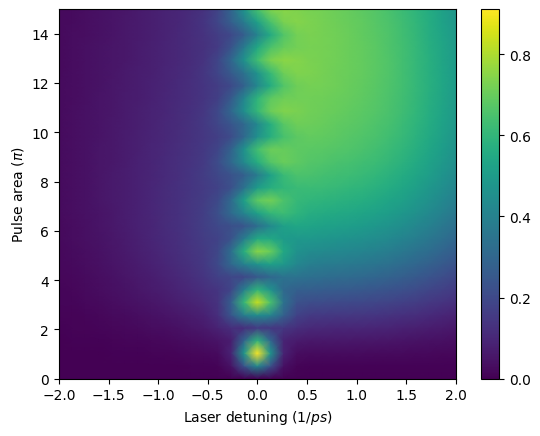

In [5]:
fig, ax = plt.subplots()
plt.pcolormesh(detunings, areas, intensity, shading='gouraud')
plt.colorbar(ax=ax)
plt.xlabel("Laser detuning ($1/ps$)")
plt.ylabel(r"Pulse area ($\pi$)")
plt.show()

From this map, we can identify two main features. First, we can see that there is a clear oscillation between bright and dark emission while increasing the pulse area at zero detuning. This shows that the emitter is undergoing Rabi oscillations due to the coherent driving. The second feature is a broad underlying resonance at a higher excitation pulse area, and when the detuning is positive (above the emitter transition line). This second feature is phonon-assisted excitation. To explore these two features in more detail, we can choose two detunings: (1) resonance $\delta=0$ and (2) phonon-assisted $\delta=0.6$ while increasing the power in finer steps.

In [6]:
areas = np.linspace(0, 20, 200)
intensity_rf = [source.mu(parameters=resonance_scan_parameters(0, {'emitter/area': a * np.pi})) for a in areas]
intensity_la = [source.mu(parameters=resonance_scan_parameters(0.6, {'emitter/area': a * np.pi})) for a in areas]

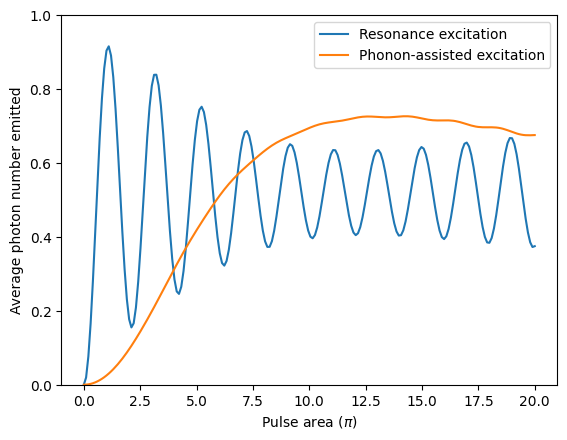

In [7]:
plt.plot(areas, intensity_rf, label='Resonance excitation')
plt.plot(areas, intensity_la, label='Phonon-assisted excitation')
plt.ylabel("Average photon number emitted")
plt.xlabel(r"Pulse area ($\pi$)")
plt.ylim([0, 1])
plt.legend()
plt.show()

In [8]:
source.photon_statistics(parameters=resonance_scan_parameters(0.6, {'emitter/area': 20 * np.pi}))

{(0,): np.float64(0.3401220176595185), (1,): np.float64(0.6444117093701884), (2,): np.float64(0.01529302521475069), (3,): np.float64(0.00017322513164937383), (4,): np.float64(2.2623894002649083e-08)}

From this plot, it is easier to see that phonon-assisted excitation can achieve a comparable emission probability to resonance excitation. In this case, the ratio is:

In [9]:
max(intensity_la)/max(intensity_rf)

0.7934283429877246

This is about 83% as bright as resonance excitation. That value is very close to the 85% measured in the lab for slightly different system parameters in [S. E. Thomas et al., *Phys. Rev. Lett.* 126, 233601 (2021)](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.126.233601).


## 3. Lifetime


The emitter dressing, relaxation, and subsequent adiabatic undressing gives rise to a very particular-looking dynamic evolution of the emitter population. Let's take a look at what this population evolution looks like for the source we defined in the previous section.

By default, the phonon-assisted source has the spontaneous emission port of the quantum dot masked so that only the cavity emission is collected for use in a circuit. This means that the spontaneous emission port is closed by default. Since we wish to monitor the lifetime of the quantum dot itself, in addition to our desired photon, we can open all closed ports after creating our source.

In [10]:
pulse = Pulse.gaussian(parameters={'width': 8}) # width in ps
source = Source.phonon_assisted(pulse=pulse,
                                purcell_factor=10,
                                regime=0.1,  # coupling regime parameter (lower is further into the weak coupling regime)
                                timescale=110,  # Purcell-enhanced decay timescale in ps
                                temperature=7,  # Temperature in Kelvin
                                material=Material.ingaas_quantum_dot())
source.output.open_all()

Now, when we wish to compute properties of the source, we must specify which port we are targeting. In this case, the unmasked source as spontaneous emission as port 0 and cavity emission as port 1. Knowing this, let's plot the lifetimes of both ports for a detuning of $\delta=0.6$ and pulse area of $\Theta = 20$, in addition to the pulse. To make things visually clear, we can scale the shapes appropriately using the 'scale' keyword. In this case, if we scale the QD population by the inverse of its decay rate, we get exactly the occupation probability of the emitter excited state.

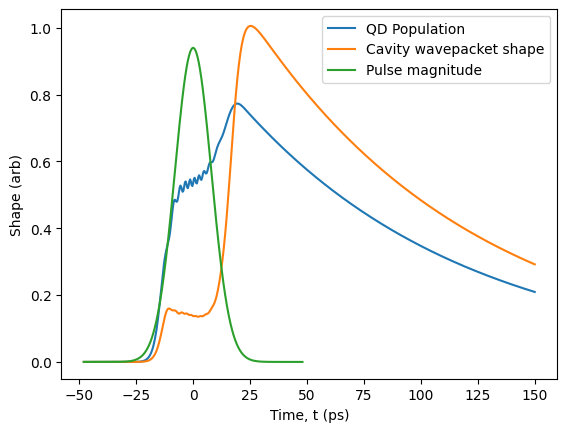

In [11]:
parameters = resonance_scan_parameters(0.6, {'emitter/area': 20 * np.pi})
source.plot_lifetime(port=0, end=150, parameters=parameters, scale=1/source.default_parameters['emitter/decay'], label='QD Population')
source.plot_lifetime(port='cavity', end=150, parameters=parameters, label='Cavity wavepacket shape', scale=150)
p = pulse.plot(scale=6, label='Pulse magnitude')
p.xlabel('Time, t (ps)')
p.show()

From this plot, we can see that the QD population increases to about 1/2 at the peak of the Gaussian pulse. This indicates that the pulse has fully dressed the system and the phonon relaxation has begun to populate the lower-energy dressed eigenstate. As the pulse turns off, the higher and lower-energy eigenstates adiabatically return to their ground and excited states, respectively. This undressing pushes the QD population up into the excited state, as illustrated by the rising population as the pulse decays. Meanwhile, the cavity begins to produce light, as illustrated by the orange curve. During the pulse, there is a remnant emission occurring, which is actually undesired as it indicates that the system has relaxed to the ground state during the pulse, allow for possible re-excitation and subsequent multi-photon emission. However, the vast majority of the emission occurs as the pulse decays and the QD population is then accelerated through the cavity mode via the Purcell effect, leading to efficient single-photon emission.

## 4. Photon statistics


Once we have set up our source, it is easy to check other characteristics, such as the amount of multi-photon emission. Let's take a look at the brightness (probability of emitting at least one photon) and intensity correlation for a $\pi$-pulse excitation compared to a $20\pi$-pulse excitation, both as a function of detuning. Recall that, in the previous section, we opened all ports of the source. To compute the photon statistics for emission from the cavity mode, we can now specify port='cavity'.

In [12]:
detunings = np.linspace(-3, 2, 200)
stats_pi = [source.photon_statistics(port='cavity', truncation=2, parameters=resonance_scan_parameters(d)) for d in detunings]
stats_20pi = [source.photon_statistics(port='cavity', truncation=2, parameters=resonance_scan_parameters(d, {'emitter/area': 20 * np.pi})) for d in detunings]

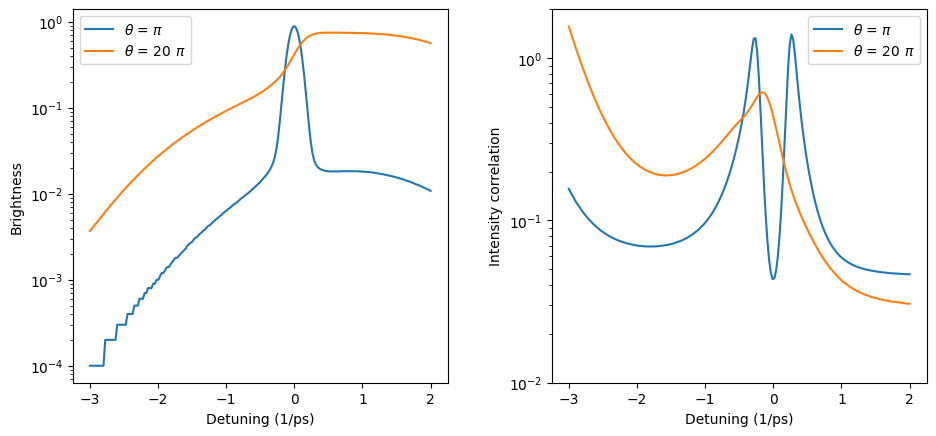

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.semilogy(detunings, [ps.beta() for ps in stats_pi], label=r'$\theta$ = $\pi$')
ax1.semilogy(detunings, [ps.beta() for ps in stats_20pi], label=r'$\theta$ = 20 $\pi$')
ax1.legend()
ax1.set(xlabel='Detuning (1/ps)', ylabel='Brightness')

ax2.semilogy(detunings, [ps.g2() for ps in stats_pi], label=r'$\theta$ = $\pi$')
ax2.semilogy(detunings, [ps.g2() for ps in stats_20pi], label=r'$\theta$ = 20 $\pi$')
ax2.legend()
ax2.set(xlabel='Detuning (1/ps)', ylabel='Intensity correlation', ylim=[0.01, 2])
fig.tight_layout(pad=3.0)

In the left panel, we can identify the QD-cavity resonance (blue curve) around a zero detuning, corresponding to the resonance excitation condition. However, we can also identify the phonon sideband as a broad lower-intensity resonance. In this case, the curve looks stepped due to rounding after the statistics truncation. At higher excitation pulse area, we can see the phonon-assisted region at positive detuning, reaching nearly as high as the peak resonance excitation value. In the right panel, we can see a very interesting double-peak feature when driving the system with a $\pi$-pulse. The dip corresponds to the resonance excitation condition, while the side peaks actually correspond to detunings where the effective Rabi frequency performs an effective $2\pi$ pulse. This quick suppression in QD population coincides with a bunching effect, pushing the intensity correlation above that of a coherent state. On the other hand, at higher pulse area of $20\pi$, we see an even smaller multi-photon emission in the phonon-assisted regime.

## 5. Custom pulse shapes


Due to the general scope of the ZPG backend, we are not restricted to pre-defined pulse shapes. Instead, we can supply our phonon-assisted source with a custom pulse shape constructed from interpolating functions and the Pulse.custom() class method.

In [14]:
from scipy.interpolate import interp1d

pulse_shape = interp1d([-20, -10, -5, 0, 5, 10, 20], [0, 0.2, 0.2, 0.1, 0.4, 0.2, 0], kind='quadratic')
pulse_phase = interp1d([-20, -10, -5, 0, 5, 10, 20], [0, -1, 1, 1, -1, 1, 1], kind='quadratic')

custom_pulse = Pulse.custom(shape=lambda t, args: args['area'] * abs(pulse_shape(t)) * np.exp(1.j * pulse_phase(t)),
                            gate = [-20, 20],  #  specify the time interval for the pulse (it will be 0 elsewhere)
                            parameters={'area': 20 * np.pi},  # specify any parameters used in the shape and their defaults
                            auto_normalise=True,  # automatically normalize the shape
                            norm=20 * np.pi)  # specify what the normalization should be for default parameters

source = Source.phonon_assisted(pulse=custom_pulse, parameters=resonance_scan_parameters(0.6),
                                purcell_factor=10, regime=0.1, timescale=110,
                                temperature=7, material=Material.ingaas_quantum_dot())
source.output.open_all()

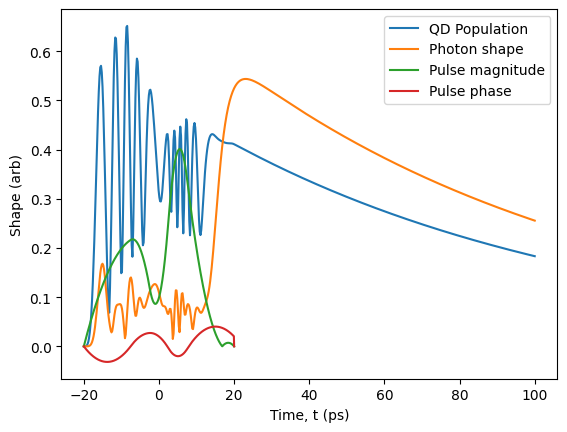

In [15]:
source.plot_lifetime(port=0, end=100, scale=1/source.default_parameters['emitter/decay'], label='QD Population')
source.plot_lifetime(port='cavity', end=100, label='Photon shape', scale=150)
custom_pulse.plot(scale=1/10, label='Pulse magnitude')
custom_pulse.plot_phase(scale=1/50, label='Pulse phase', xlabel='Time, t (ps)').show()